In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("cs1090a_hw2.ipynb")

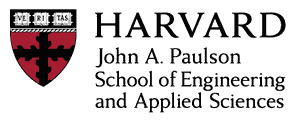

# CS1090A Introduction to Data Science
## Homework 2: kNN, Linear and Polynomial Regression, and Model Selection
### Predicting the sale price of a house in Ames, Iowa

**Harvard University**<br/>
**Fall 2026**<br/>
**Instructors**: Pavlos Protopapas, Kevin Rader, and Chris Gumb

<hr style="height:2.4pt">

In [2]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import display

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")

In [3]:
# For calculating total notebook runtime
notebook_start = time.time()

In [4]:
style = '''<style>
h2, h3, h4 {
    background-color: #7efcf5;
    border-left: 5px solid #7ec4fc;
    border-right: 5px solid #7ec4fc;
    padding: 0em;
    color: #1F2937;
}
h3 {
    background-color: #7efcf5;
    border-top: 5px solid #7ec4fc;
    border-left: 5px solid #7ec4fc;
    border-right: 5px solid #7ec4fc;
    padding: 0.5em;
}
div.md {
    border-left: 5px solid #7ec4fc;
    border-right: 5px solid #7ec4fc;
    border-bottom: 5px solid #7ec4fc;
    padding: 0.5em;
}
div.prompt {
    background: #d1ffbd;
    border: thin solid black;
    border-radius: 2px;
    padding: 5px;
    margin: 0.5em 0;
    color: #1F2937;
}
/* A colour on the box does not reach <code> or <a> inside it. JupyterLab's dark
   theme gives inline code background-color: var(--jp-layout-color2) (#424242) and
   colours links #64b5f6, so setting only the box colour would put dark text on a
   dark code background. Code and links outside a box are left alone, where the
   theme's own pairing is already right. */
div.prompt code, div.alert code {
    background: rgba(0, 0, 0, 0.06);
    color: #1F2937;
}
div.prompt a, div.alert a {
    color: #1D4ED8;
}
</style>'''
display.display(display.HTML(style))

## Assignment Overview

**A house in Ames, Iowa is about to be listed. What is it worth, and how much should anyone
trust that number?**

You will build three models to answer it, each better than the last. At the end you will
score the final model on houses it has never seen. Then you will say why that score might
be too high or too low.

**The data.** The Ames Housing data (De Cock, 2011) covers 2,930 houses sold in Ames
between 2006 and 2010, with 81 columns each. The target is `Sale_Price`, in dollars. The
file ships with the assignment as `data/ames.csv`; nothing here needs the network. The
graded questions use 23 of the columns. The AC209A question uses all 81.

**Structure** (9 questions + wrap-up; CS1090A graded out of 60, AC209A out of 65):

*Part 1: one predictor* (20 pts)
1. The target and living area (4 pts)
2. Simple linear regression (12 pts)
3. k-nearest neighbours (4 pts)

*Part 2: more predictors* (15 pts)

4. Multiple regression (5 pts)
5. One-hot encoding (6 pts)
6. Ordinal encoding (4 pts)

*Part 3: model selection* (22 pts)

7. Polynomial regression (8 pts)
8. Cross-validation (9 pts)
9. The final pipeline (5 pts)

*AC209A only:* bias and variance (5 pts, required for AC209A; CS1090A students skip it)

*Wrap-up* (3 pts): score on the test set once, then report your hours.


## Instructions

<div class="prompt" style="background: lightgreen; border: thin solid black; border-radius: 2px; padding: 5px; color: #1F2937;">

**General**
- To submit, follow the instructions on the Canvas assignment page.
- **CS1090A is graded out of 60; AC209A out of 65.** The question marked *AC209A only* (5 points) is required for AC209A. CS1090A students skip it and lose nothing.
- **Use the provided splits. Do not touch `test_df` or `test` before the wrap-up.** Each question says which rows to fit on and which to score on.
- Plots need axis labels, a title, and a legend when there is more than one series. A reader should understand the plot without reading the code.
- When asked what a result means, answer about houses, not about arrays.
- The automated tests are **smoke tests**. They check that a variable exists, has the right type and shape, and holds a plausible value. Passing them earns the autograded points; the rest of the credit comes from the rubric.
- Your notebook must run from top to bottom: "Restart Kernel and Run All Cells" must finish without error. It must not use the network: everything it computes comes from `data/ames.csv`.
- You may add cells. Write each answer where the question asks for it.
- **Before submitting, Restart Kernel and Run All Cells** and check that every output is visible.

**Use of AI tools**

You may use AI tools. You are accountable for everything you submit: you must understand it and be able to explain it.

- Written answers must be your own words.
- Quizzes and midterms ask you to explain and apply these methods without a tool.
</div>

## Setup: the data, the columns, and the split

Run these cells and do not change them. Every question uses the variables they define.

### The columns the graded questions use

The file has 81 columns. The AC209A question uses all of them. Everything graded for
CS1090A uses the 23 listed here, plus one column that is listed but excluded.

<details>
<summary><b>Column descriptions</b> (click to expand)</summary>

| Column | What it records |
|---|---|
| `Gr_Liv_Area` | above-ground living area, square feet |
| `Total_Bsmt_SF` | basement area, square feet (0 if no basement) |
| `First_Flr_SF` | first-floor area, square feet |
| `Garage_Cars` | garage capacity, in cars (0 if no garage) |
| `Garage_Area` | garage area, square feet (0 if no garage) |
| `Year_Built` | year the house was built |
| `Year_Remod_Add` | year of the last remodel (equals `Year_Built` if never remodelled) |
| `Full_Bath` | full bathrooms above ground |
| `TotRms_AbvGrd` | rooms above ground, not counting bathrooms |
| `Lot_Area` | lot size, square feet |
| `Lot_Frontage` | feet of street connected to the lot. **Excluded from every model here:** 490 of its zeros are missing values, not measurements |
| `Mas_Vnr_Area` | masonry veneer area, square feet |
| `Year_Sold` | year of the sale, 2006 to 2010 |
| `Neighborhood` | one of 28 named areas of Ames |
| `Overall_Qual` | rating of the house's material and finish, 10 levels from `Very_Poor` to `Very_Excellent` |
| `House_Style` | e.g. one storey, two storeys, split level |
| `Sale_Condition` | e.g. `Normal`, `Partial` (a new house sold before completion), `Abnorml` (a foreclosure or short sale) |
| `Kitchen_Qual` | kitchen quality, 5 levels |
| `Bldg_Type` | single-family, townhouse, duplex, and so on |
| `Misc_Feature` | a shed, tennis court or similar; missing means none |
| `Exter_Qual` | exterior material quality, 4 levels |
| `Mas_Vnr_Type` | type of masonry veneer; missing means none |
| `Central_Air` | `Y` or `N` |
| `Sale_Price` | **the target**, in dollars |

</details>


In [5]:
# Provided: load the file and build the core frame.
ames = pd.read_csv("data/ames.csv")
print(f"{ames.shape[0]:,} houses x {ames.shape[1]} columns in the file")

NUMERIC_COLS = ["Gr_Liv_Area", "Total_Bsmt_SF", "First_Flr_SF", "Garage_Cars", "Garage_Area",
                "Year_Built", "Year_Remod_Add", "Full_Bath", "TotRms_AbvGrd", "Lot_Area",
                "Mas_Vnr_Area", "Year_Sold"]
CATEGORICAL_COLS = ["Neighborhood", "Overall_Qual", "House_Style", "Sale_Condition",
                    "Kitchen_Qual", "Bldg_Type", "Misc_Feature", "Exter_Qual", "Mas_Vnr_Type",
                    "Central_Air"]
TARGET = "Sale_Price"
CORE_COLS = NUMERIC_COLS + CATEGORICAL_COLS + [TARGET]

core = ames[CORE_COLS]
print(f"{core.shape[0]:,} houses x {core.shape[1]} columns in the core frame")
display.display(core.head(3))

2,930 houses x 81 columns in the file
2,930 houses x 23 columns in the core frame


,Gr_Liv_Area,Total_Bsmt_SF,First_Flr_SF,Garage_Cars,Garage_Area,Year_Built,Year_Remod_Add,Full_Bath,TotRms_AbvGrd,Lot_Area,...,Overall_Qual,House_Style,Sale_Condition,Kitchen_Qual,Bldg_Type,Misc_Feature,Exter_Qual,Mas_Vnr_Type,Central_Air,Sale_Price
0,1656,1080,1656,2,528,1960,1960,1,7,31770,...,Above_Average,One_Story,Normal,Typical,OneFam,NaN,Typical,Stone,Y,215000
1,896,882,896,1,730,1961,1961,1,5,11622,...,Average,One_Story,Normal,Typical,OneFam,NaN,Typical,NaN,Y,105000
2,1329,1329,1329,1,312,1958,1958,1,6,14267,...,Above_Average,One_Story,Normal,Good,OneFam,Gar2,Typical,BrkFace,Y,172000


### The split

Two splits, made once.

- `dev_df` and `test_df` split the full file: 2,197 houses to develop the model on, and
  733 houses that no model sees until the wrap-up. `dev` and `test` are the same rows,
  restricted to the core columns.
- `train` and `val` split `dev` again: 1,647 rows to fit on and 550 to validate on.
  **Parts 1 and 2 fit on `train` and score on `val`.**
- Part 3 cross-validates on all of `dev`. Five times, it fits on four fifths of `dev` and
  scores on the remaining fifth. Each fold has its own training and validation rows.

The random seeds fix which houses land where, so your numbers match the tests.


In [6]:
# Provided: the two splits. Made once and reused by every question below.
dev_df, test_df = train_test_split(ames, test_size=0.25, random_state=109)
dev, test = dev_df[CORE_COLS], test_df[CORE_COLS]

# Parts 1 and 2 fit on train and validate on val. Part 3 cross-validates on all of dev.
train, val = train_test_split(dev, test_size=0.25, random_state=109)

print(f"dev {len(dev):,} houses   test {len(test):,} houses (not touched until the wrap-up)")
print(f"  dev splits again: train {len(train):,} houses, val {len(val):,} houses")

dev 2,197 houses   test 733 houses (not touched until the wrap-up)
  dev splits again: train 1,647 houses, val 550 houses


# Part 1. One predictor

The first models use one column, `Gr_Liv_Area`, the above-ground living area in square
feet. Part 1 asks how well one number predicts price, with a straight line and then with
k-nearest neighbours.

## Question 1: The target and living area

### Q1.1 Distribution of the target

This question uses the whole file, `core`. Nothing is fitted from it. Every later plot and
fit uses the dev rows.

<div class=prompt>

**Artifact:**
- a histogram of `core["Sale_Price"]`;
- `price_skew`: `core["Sale_Price"].skew()`. Skewness is 0 for a symmetric distribution,
  positive when the long tail is on the right, negative when it is on the left.
</div>


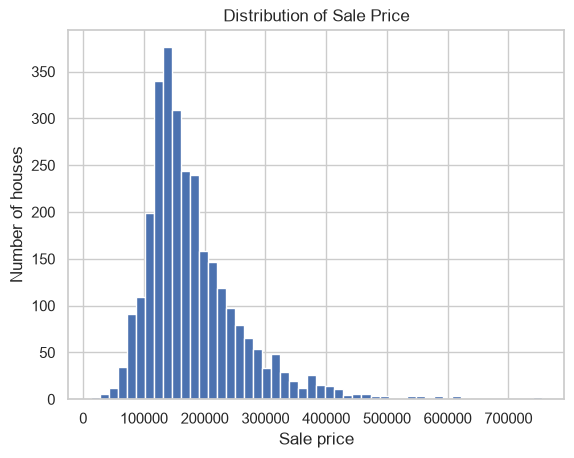

skew: 1.7435000757376466


In [7]:
plt.hist(core["Sale_Price"], bins=50)
plt.xlabel("Sale price")
plt.ylabel("Number of houses")
plt.title("Distribution of Sale Price")
plt.show()

price_skew = core["Sale_Price"].skew()
print("skew:", price_skew)

In [8]:
grader.check("q1_1")

q1_1 results: All test cases passed!

### Q1.2 Living area against price

From here on, use `dev` for plots and summaries, and `train` and `val` for fits and
scores.

<div class=prompt>

**Artifact:**
- a scatter plot of `Sale_Price` against `Gr_Liv_Area` for the rows in `dev`;
- `r_gr_liv`: the correlation between the two columns on those rows.
</div>


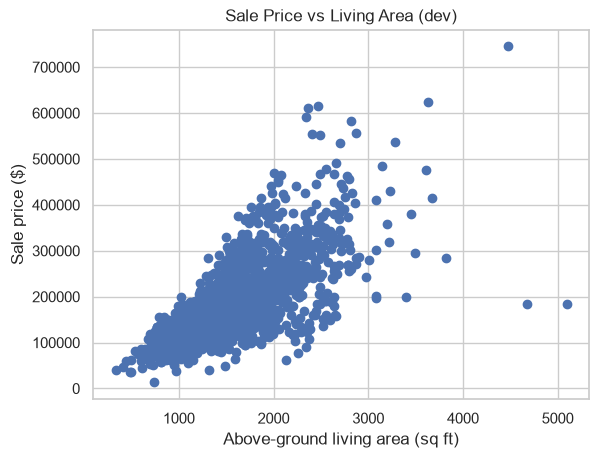

correlation: 0.7009529793600766


In [9]:
plt.scatter(dev["Gr_Liv_Area"], dev["Sale_Price"])
plt.xlabel("Above-ground living area (sq ft)")
plt.ylabel("Sale price ($)")
plt.title("Sale Price vs Living Area (dev)")
plt.show()

r_gr_liv = dev["Gr_Liv_Area"].corr(dev["Sale_Price"])
print("correlation:", r_gr_liv)

In [10]:
grader.check("q1_2")

q1_2 results: All test cases passed!

## Question 2: Simple linear regression

### Q2.1 Fit the line

Pass the predictor as `train[["Gr_Liv_Area"]]`, with two sets of brackets. scikit-learn
needs a two-dimensional table of predictors.

<div class=prompt>

**Artifact:**
- `slr`: a `LinearRegression` fitted on `train`, predicting `Sale_Price` from
  `Gr_Liv_Area`;
- `slr_slope` and `slr_intercept`: its two fitted numbers;
- `slr_val_r2`: its R² on `val`.

**Written answer:**
- the slope, as one sentence about two houses, in dollars per square foot;
- the value of `Gr_Liv_Area` for which the intercept is the prediction, and whether any
  house in `train` has it.
</div>


In [11]:
X_train = train[["Gr_Liv_Area"]]
y_train = train["Sale_Price"]
X_val = val[["Gr_Liv_Area"]]
y_val = val["Sale_Price"]

slr = LinearRegression()
slr.fit(X_train, y_train)

slr_slope = slr.coef_[0]
slr_intercept = slr.intercept_
print("slope:", slr_slope)
print("intercept:", slr_intercept)

slr_val_r2 = slr.score(X_val, y_val)
print("val R2:", slr_val_r2)

print("smallest Gr_Liv_Area in train:", train["Gr_Liv_Area"].min())

slope: 110.23672489588094
intercept: 15891.707016312575
val R2: 0.5233308573268634
smallest Gr_Liv_Area in train: 334


Comparing two houses whose living areas differ by one square foot, the model predicts the larger one to sell for 110.24 more.
The intercept ($15,891.71) is the predicted sale price for a house with Gr_Liv_Area = 0. No house in train has this value. The smallest is 334 sq ft, so the intercept has no meaningful real world interpretation on its own.


In [12]:
grader.check("q2_1")

q2_1 results: All test cases passed!

### Q2.2 Residual plot

A **residual** is the actual price minus the predicted price. A **residual plot** puts
fitted values on the horizontal axis and residuals on the vertical, with a line at zero.

Two patterns matter. A **curve** means the residuals are mostly positive over one range of
fitted values and mostly negative over another, so the line has the wrong shape. A **band
that widens or narrows** means the residuals stay centred on zero but their spread changes
along the axis. The line then has the right shape, but the error is larger for some houses
than for others.

<div class=prompt>

**Artifact:**
- `slr_residuals`: the residuals of `slr` on `train` (actual minus predicted);
- a scatter of those residuals against the fitted values, with a horizontal line at zero;
- the standard deviation of the residuals within each quarter of the fitted values.

**Written answer:**
- which of the two patterns the plot shows;
- what about the distribution of `Sale_Price` (Q1.1) explains where the spread is largest.
</div>


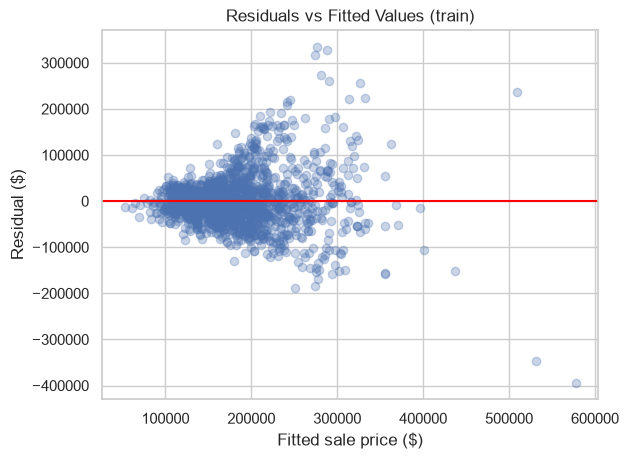

0    24308.833742
1    33445.429412
2    54443.564298
3    92250.376906
Name: Sale_Price, dtype: float64


In [13]:
train_pred = slr.predict(X_train)
slr_residuals = y_train - train_pred
plt.scatter(train_pred, slr_residuals, alpha=0.3)
plt.axhline(0, color="red")
plt.xlabel("Fitted sale price ($)")
plt.ylabel("Residual ($)")
plt.title("Residuals vs Fitted Values (train)")
plt.show()
quarters = pd.qcut(train_pred, 4, labels=False)
print(slr_residuals.groupby(quarters).std())

The plot shows a fan shape rather than a curve. There is no linear relationship between Sale price and Residual and the residual is trend to stay around 0, but become scatter as the sale price goes higher. In Q1.1, Sale_Price is right-skewed. Most houses sell for $100k–$200k, and a long tail of expensive houses stretches out to the right. Based on the residual plot we can find that expensive houses differ from one another by much larger dollar amounts.

In [14]:
grader.check("q2_2")

q2_2 results: All test cases passed!

### Q2.3 Log-transformed target

Fit the same line with `np.log(train["Sale_Price"])` as the target. On the log scale, equal
*ratios* of price become equal *differences*: a rise from 100,000 to 200,000 is the same
step as a rise from 200,000 to 400,000. With slope *b* per square foot, 100 extra square feet multiply the
predicted price by *e*<sup>100*b*</sup>.

<div class=prompt>

**Artifact:**
- `slr_log`: a `LinearRegression` fitted on `train`, predicting `np.log(Sale_Price)` from
  `Gr_Liv_Area`;
- `slr_log_slope`: its slope;
- `pct_per_100`: the percentage change in predicted price for 100 extra square feet,
  `(np.exp(100 * slr_log_slope) - 1) * 100`;
- the residual plot for this model beside the one from Q2.2, with the same
  quarter-by-quarter standard deviations, and the widest-to-narrowest ratio of those
  standard deviations printed for both scales. Do not compare this model's R² with
  Q2.1's; the two predict different quantities.

**Written answer:**
- did the band stop widening: yes, partly, or no.
</div>


log slope: 0.000556473351408334
% change per 100 sq ft: 5.722477195872622


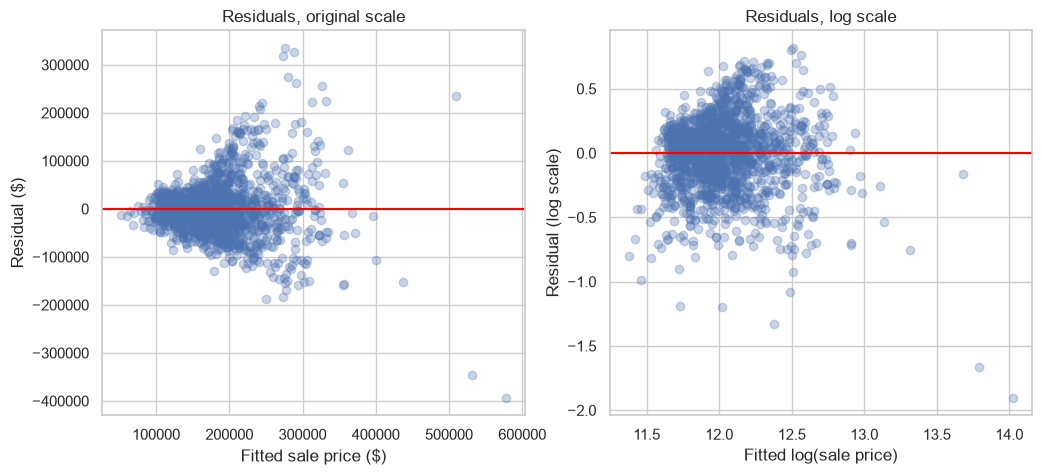

original scale SD by quarter:
0    24308.833742
1    33445.429412
2    54443.564298
3    92250.376906
Name: Sale_Price, dtype: float64
log scale SD by quarter:
0    0.241330
1    0.225417
2    0.282914
3    0.366379
Name: Sale_Price, dtype: float64
widest / narrowest, original: 3.7949322408546355
widest / narrowest, log: 1.6253357082699442


In [15]:
y_train_log = np.log(train["Sale_Price"])
slr_log = LinearRegression()
slr_log.fit(X_train, y_train_log)
slr_log_slope = slr_log.coef_[0]
print("log slope:", slr_log_slope)
pct_per_100 = (np.exp(100 * slr_log_slope) - 1) * 100
print("% change per 100 sq ft:", pct_per_100)
log_pred = slr_log.predict(X_train)
log_residuals = y_train_log - log_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(train_pred, slr_residuals, alpha=0.3)
axes[0].axhline(0, color="red")
axes[0].set_xlabel("Fitted sale price ($)")
axes[0].set_ylabel("Residual ($)")
axes[0].set_title("Residuals, original scale")
axes[1].scatter(log_pred, log_residuals, alpha=0.3)
axes[1].axhline(0, color="red")
axes[1].set_xlabel("Fitted log(sale price)")
axes[1].set_ylabel("Residual (log scale)")
axes[1].set_title("Residuals, log scale")

plt.show()
sd_orig = slr_residuals.groupby(pd.qcut(train_pred, 4, labels=False)).std()
sd_log = log_residuals.groupby(pd.qcut(log_pred, 4, labels=False)).std()
print("original scale SD by quarter:")
print(sd_orig)
print("log scale SD by quarter:")
print(sd_log)
print("widest / narrowest, original:", sd_orig.max() / sd_orig.min())
print("widest / narrowest, log:", sd_log.max() / sd_log.min())

Partly. On the log scale, the residual band has roughly constant width across fitted values, so the fan shape is gone. On the original dollar scale, the band still widens.


In [16]:
grader.check("q2_3")

q2_3 results: All test cases passed!

## Question 3: k-nearest neighbours

Fit `KNeighborsRegressor` on `Gr_Liv_Area` for each `k` in a list, fitting on `train` and
scoring on `val`. Predict `Sale_Price` in dollars, not its logarithm.

<div class=prompt>

**Artifact:**
- `knn_table`: a DataFrame with columns `k`, `train_r2`, `val_r2`, one row per `k`, for
  `[1, 2, 3, 5, 10, 20, 30, 50, 100, 200, 500]` or a similar spread of at least eight
  values;
- a plot of both R² columns against `k`, with `k` on a log scale and the line's validation
  R² from Q2.1 drawn for comparison;
- `best_k`: the `k` with the highest validation R².

**Written answer:**
- the range of `k` over which validation R² is within 0.005 of its maximum.
</div>


      k  train_r2    val_r2
0     1  0.754926  0.085600
1     2  0.708806  0.329463
2     3  0.651484  0.404691
3     5  0.597559  0.437956
4    10  0.541799  0.473615
5    20  0.516849  0.488545
6    30  0.509529  0.493227
7    50  0.505699  0.494279
8   100  0.498229  0.490162
9   200  0.481684  0.478183
10  500  0.434561  0.438200


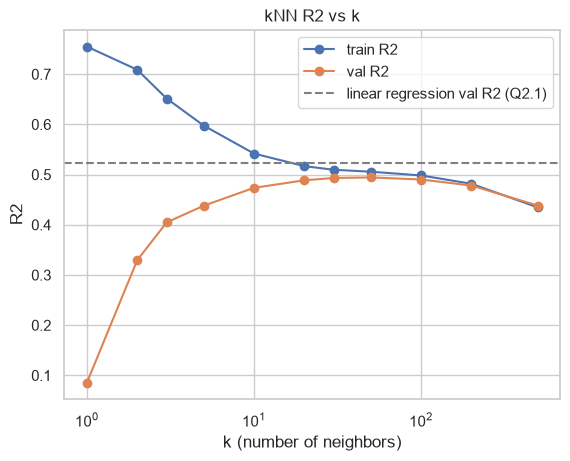

best k: 50
     k  train_r2    val_r2
6   30  0.509529  0.493227
7   50  0.505699  0.494279
8  100  0.498229  0.490162


In [17]:
k_list = [1, 2, 3, 5, 10, 20, 30, 50, 100, 200, 500]
train_r2_list = []
val_r2_list = []

for k in k_list:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_r2_list.append(knn.score(X_train, y_train))
    val_r2_list.append(knn.score(X_val, y_val))

knn_table = pd.DataFrame({"k": k_list, "train_r2": train_r2_list, "val_r2": val_r2_list})
print(knn_table)

plt.plot(knn_table["k"], knn_table["train_r2"], marker="o", label="train R2")
plt.plot(knn_table["k"], knn_table["val_r2"], marker="o", label="val R2")
plt.axhline(slr_val_r2, color="gray", linestyle="--", label="linear regression val R2 (Q2.1)")
plt.xscale("log")
plt.xlabel("k (number of neighbors)")
plt.ylabel("R2")
plt.title("kNN R2 vs k")
plt.legend()
plt.show()

best_k = int(knn_table.loc[knn_table["val_r2"].idxmax(), "k"])
print("best k:", best_k)
print(knn_table[knn_table["val_r2"] >= knn_table["val_r2"].max() - 0.005])

(k = 30, 50, 100)


In [18]:
grader.check("q3")

q3 results: All test cases passed!

# Part 2. More predictors

One predictor explains about half of the variation in price. Part 2 adds the other
numeric columns, then two categorical columns, and measures the validation-R² gain from each.
Everything here is fitted on `train` and scored on `val`.


## Question 4: Multiple regression

Pass a list of column names to `.fit()`. `model.coef_` then has one entry per column. Each
coefficient compares two rows that differ in that column and match on all the others.

<div class=prompt>

**Artifact:**
- `mlr`: a `LinearRegression` fitted on `train[NUMERIC_COLS]`, predicting `Sale_Price`;
- `mlr_val_r2`: its R² on `val`;
- `mlr_coefs`: a `pd.Series` of its coefficients, indexed by column name.

**Written answer:**
- the gain in validation R² over Q2.1;
- two columns in `NUMERIC_COLS` that are held fixed when reading the `Gr_Liv_Area`
  coefficient here, and were left out of the Q2.1 model so that their effect was counted
  in its slope.
</div>


In [19]:
mlr = LinearRegression()
mlr.fit(train[NUMERIC_COLS], y_train)
mlr_val_r2 = mlr.score(val[NUMERIC_COLS], y_val)
print("val R2:", mlr_val_r2)
print("gain over Q2.1:", mlr_val_r2 - slr_val_r2)
mlr_coefs = pd.Series(mlr.coef_, index=NUMERIC_COLS)
print(mlr_coefs)

val R2: 0.8034915546578372
gain over Q2.1: 0.2801606973309738
Gr_Liv_Area         71.117716
Total_Bsmt_SF       43.290683
First_Flr_SF        -0.849863
Garage_Cars       6917.428407
Garage_Area         43.007353
Year_Built         446.134229
Year_Remod_Add     677.244372
Full_Bath        -9267.488555
TotRms_AbvGrd    -2523.902109
Lot_Area             0.487675
Mas_Vnr_Area        38.294860
Year_Sold         -315.356979
dtype: float64


The gain in validation R^2 over Q2.1 is 0.28. 
Two columns: Total_Bsmt_SF, Garage_Area

In [20]:
grader.check("q4")

q4 results: All test cases passed!

## Question 5: One-hot encoding

A linear model cannot take the string `"Northridge"`. A categorical column is turned into
indicator columns, one per level, with one level dropped. The dropped level is the
baseline the other coefficients are measured against.

<div class=prompt>

**Artifact:**
- `nbhd_model`: a `LinearRegression` fitted on `train`'s numeric columns plus
  `pd.get_dummies(train[["Neighborhood"]], drop_first=True, dtype=int)`. Encode `train`
  and `val` separately, then `reindex(columns=<the train columns>, fill_value=0)` on
  the validation matrix;
- `nbhd_val_r2`: its R² on `val`;
- `top3_neighborhoods`: the three neighbourhood names with the largest coefficients, in
  order, as plain strings such as `"Northridge"` (`pd.get_dummies` names the columns
  `Neighborhood_Northridge`; strip the prefix).

**Written answer:**
- the neighbourhood every coefficient is measured against;
- of the three in `top3_neighborhoods`, the one with the fewest houses in `train`, and
  its count;
- the row the `reindex` step produces for a `val` house whose neighbourhood is absent
  from `train` (`set(val["Neighborhood"]) - set(train["Neighborhood"])` finds it).
</div>


In [21]:
train_nbhd = pd.get_dummies(train[["Neighborhood"]], drop_first=True, dtype=int)
val_nbhd = pd.get_dummies(val[["Neighborhood"]], drop_first=True, dtype=int)
X_train_nbhd = pd.concat([train[NUMERIC_COLS], train_nbhd], axis=1)
X_val_nbhd = pd.concat([val[NUMERIC_COLS], val_nbhd], axis=1)
X_val_nbhd = X_val_nbhd.reindex(columns=X_train_nbhd.columns, fill_value=0)
nbhd_model = LinearRegression()
nbhd_model.fit(X_train_nbhd, y_train)
nbhd_val_r2 = nbhd_model.score(X_val_nbhd, y_val)
print("val R2:", nbhd_val_r2)
nbhd_coefs = pd.Series(nbhd_model.coef_, index=X_train_nbhd.columns)
nbhd_coefs = nbhd_coefs[train_nbhd.columns].sort_values(ascending=False)
print(nbhd_coefs.head(3))
top3_neighborhoods = [name.replace("Neighborhood_", "") for name in nbhd_coefs.index[:3]]
print(top3_neighborhoods)
print("baseline:", sorted(train["Neighborhood"].unique())[0])
print(train["Neighborhood"].value_counts()[top3_neighborhoods])
missing = set(val["Neighborhood"]) - set(train["Neighborhood"])
print("in val but not in train:", missing)
display.display(X_val_nbhd[val["Neighborhood"].isin(missing)].T)

val R2: 0.8189799620482408
Neighborhood_Green_Hills           125523.185275
Neighborhood_Stone_Brook            80036.290536
Neighborhood_Northridge_Heights     71895.429183
dtype: float64
['Green_Hills', 'Stone_Brook', 'Northridge_Heights']
baseline: Bloomington_Heights
Neighborhood
Green_Hills            1
Stone_Brook           28
Northridge_Heights    99
Name: count, dtype: int64
in val but not in train: {'Landmark'}


,2788
Gr_Liv_Area,1320
Total_Bsmt_SF,630
First_Flr_SF,630
Garage_Cars,2
Garage_Area,484
Year_Built,1993
Year_Remod_Add,1994
Full_Bath,2
TotRms_AbvGrd,5
Lot_Area,3612


Bloomington_Heights. Each neighbourhood coefficient is the predicted price difference relative to an otherwise identical house in Bloomington_Heights. 

Green_Hills, with only 1 house in train.

All Neighborhood columns are 0, so the model treats the Landmark house as if it were in the baseline, Bloomington_Heights.

In [22]:
grader.check("q5")

q5 results: All test cases passed!

## Question 6: Ordinal encoding

`Overall_Qual` has ten ordered levels:

`Very_Poor` < `Poor` < `Fair` < `Below_Average` < `Average` < `Above_Average` < `Good` <
`Very_Good` < `Excellent` < `Very_Excellent`

**Ordinal** encoding maps the levels to 1–10 and fits one coefficient: a fixed dollar
amount per step, which assumes every step is worth the same. **One-hot** encoding fits one
coefficient per level and assumes nothing about the spacing.

<div class=prompt>

**Artifact:**
- `qual_map`: a dict mapping each level name to its position 1 to 10;
- `qual_ordinal_val_r2`: validation R² of a `LinearRegression` on `train`'s numeric
  columns plus `Overall_Qual.map(qual_map)`;
- `qual_onehot_val_r2`: validation R² of the same model with `Overall_Qual` one-hot
  encoded instead (`drop_first=True`, `reindex` the validation columns as in Q5);
- `qual_steps`: a `pd.Series` of that model's ten `Overall_Qual` coefficients (0 for the
  dropped level), indexed by level in the order above, followed by `.diff()`; print it.

**Written answer:**
- whether the steps in `qual_steps` are roughly equal: yes or no.
</div>


In [23]:
QUAL_LEVELS = ["Very_Poor", "Poor", "Fair", "Below_Average", "Average",
               "Above_Average", "Good", "Very_Good", "Excellent",
               "Very_Excellent"]
qual_map = {level: i + 1 for i, level in enumerate(QUAL_LEVELS)}

# ordinal: one column, 1 to 10
X_train_ord = train[NUMERIC_COLS].assign(
    Overall_Qual=train["Overall_Qual"].map(qual_map))
X_val_ord = val[NUMERIC_COLS].assign(
    Overall_Qual=val["Overall_Qual"].map(qual_map))
qual_ordinal = LinearRegression().fit(X_train_ord, y_train)
qual_ordinal_val_r2 = qual_ordinal.score(X_val_ord, y_val)
print("ordinal val R2:", qual_ordinal_val_r2)

# one-hot: one column per level, first level dropped,
# val reindexed as in Q5
train_qual = pd.get_dummies(train[["Overall_Qual"]], drop_first=True,
                            dtype=int)
val_qual = pd.get_dummies(val[["Overall_Qual"]], drop_first=True,
                          dtype=int)
X_train_qual = pd.concat([train[NUMERIC_COLS], train_qual], axis=1)
X_val_qual = pd.concat([val[NUMERIC_COLS], val_qual], axis=1)
X_val_qual = X_val_qual.reindex(columns=X_train_qual.columns,
                                fill_value=0)
qual_onehot = LinearRegression().fit(X_train_qual, y_train)
qual_onehot_val_r2 = qual_onehot.score(X_val_qual, y_val)
print("one-hot val R2:", qual_onehot_val_r2)

# The dropped level is the only one without an indicator column;
# its coefficient is 0.
qual_coefs = pd.Series(qual_onehot.coef_, index=X_train_qual.columns)
no_column = [level for level in QUAL_LEVELS
             if f"Overall_Qual_{level}" not in qual_coefs.index]
assert len(no_column) == 1, "expected exactly one dropped level"
print("dropped level:", no_column[0])
qual_levels_coef = pd.Series(
    {level: qual_coefs.get(f"Overall_Qual_{level}", 0.0)
     for level in QUAL_LEVELS})
qual_steps = qual_levels_coef.diff()
qual_counts = train["Overall_Qual"].value_counts().reindex(QUAL_LEVELS)
print(pd.DataFrame({"coef": qual_levels_coef, "qual_steps": qual_steps,
                    "houses_in_train": qual_counts}).round(0))

ordinal val R2: 0.8321381519632229
one-hot val R2: 0.848852363438095
dropped level: Above_Average
                    coef  qual_steps  houses_in_train
Very_Poor       -12667.0         NaN                1
Poor            -20482.0     -7815.0                8
Fair            -26550.0     -6068.0               17
Below_Average   -17442.0      9109.0              118
Average          -7263.0     10179.0              469
Above_Average        0.0      7263.0              419
Good             16403.0     16403.0              342
Very_Good        54732.0     38329.0              183
Excellent       131247.0     76515.0               72
Very_Excellent  141135.0      9888.0               18


No. The steps range from about -8,000 to +77,000 dollars. From Fair up to Good each step adds 7,000 to 16,000, but Good to Very_Good adds 38,000 and Very_Good to Excellent adds 77,000. The two lowest steps are negative and the last one adds only 10,000, but those rest on very few houses (1, 8 and 17 at the bottom, 18 at Very_Excellent), so they are noisy. One-hot also fits val better than ordinal (R² 0.849 vs 0.832).

In [24]:
grader.check("q6")

q6 results: All test cases passed!

# Part 3. Model selection

Parts 1 and 2 improved models by giving them more information. A model can also be given
more *flexibility*. Past some point, that makes its predictions worse on new houses even
as its fit to the houses it has seen keeps improving. Part 3 shows how to find that point.

Part 3 adds **cross-validation** on all 2,197 rows of `dev`, because a score from one split
moves a great deal when the split moves. Q7 keeps the single `train`/`val` split so that Q8
can compare the two. Do not fit, score, plot, or choose a model using `test` until the
wrap-up.


## Question 7: Polynomial regression

### Q7.1 Degree scan on one split

`make_pipeline(PolynomialFeatures(degree), StandardScaler(), LinearRegression())` fits a
polynomial of the given degree. The scaler between the expansion and the regression keeps
high degrees numerically stable. The helper below is that pipeline.


In [25]:
# Provided: the polynomial pipeline. Degree is the one argument.
def polynomial_model(degree):
    """Polynomial regression of the given degree, with the scaler between expansion and fit."""
    return make_pipeline(PolynomialFeatures(degree), StandardScaler(), LinearRegression())

<div class=prompt>

**Artifact:**
- `poly_table`: a DataFrame with one row per degree from 1 to 10 and columns `degree`,
  `train_r2`, `val_r2`, from `polynomial_model(degree)` fitted on
  `train[["Gr_Liv_Area"]]` to predict `Sale_Price`, scored on `train` and on `val`;
- a plot of both columns against degree.

The provided cell **below** draws the fitted curves for degrees 1, 3, 6 and 10 over the
training houses.
</div>


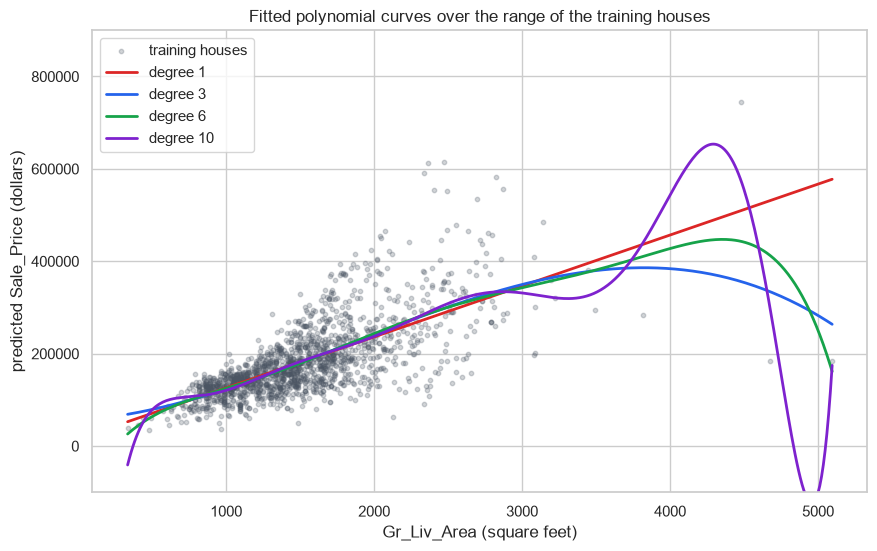

the three largest houses in the training rows:


,Gr_Liv_Area,Sale_Price,Neighborhood,Sale_Condition
2180,5095,183850,Edwards,Partial
2181,4676,184750,Edwards,Partial
1760,4476,745000,Northridge,Abnorml


In [26]:
# Provided: what the fitted curves look like at four of the degrees, over the training houses.
grid = pd.DataFrame({"Gr_Liv_Area": np.linspace(train["Gr_Liv_Area"].min(), train["Gr_Liv_Area"].max(), 400)})

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(train["Gr_Liv_Area"], train["Sale_Price"], s=10, alpha=0.25, color="#4B5563", label="training houses")
for degree, colour in zip([1, 3, 6, 10], ["#DC2626", "#2563EB", "#16A34A", "#7E22CE"]):
    curve = polynomial_model(degree).fit(train[["Gr_Liv_Area"]], train["Sale_Price"])
    ax.plot(grid["Gr_Liv_Area"], curve.predict(grid), linewidth=2, color=colour, label=f"degree {degree}")
ax.set_ylim(-100_000, 900_000)
ax.set_xlabel("Gr_Liv_Area (square feet)")
ax.set_ylabel("predicted Sale_Price (dollars)")
ax.set_title("Fitted polynomial curves over the range of the training houses")
ax.legend()
plt.show()

print("the three largest houses in the training rows:")
display.display(train.sort_values("Gr_Liv_Area", ascending=False)[["Gr_Liv_Area", "Sale_Price", "Neighborhood", "Sale_Condition"]].head(3))

   degree  train_r2    val_r2
0       1  0.481324  0.523331
1       2  0.490526  0.514004
2       3  0.499373  0.511201
3       4  0.500019  0.515684
4       5  0.500544  0.518438
5       6  0.502368  0.513102
6       7  0.502375  0.512450
7       8  0.502387  0.512698
8       9  0.502550  0.512902
9      10  0.509285  0.500785


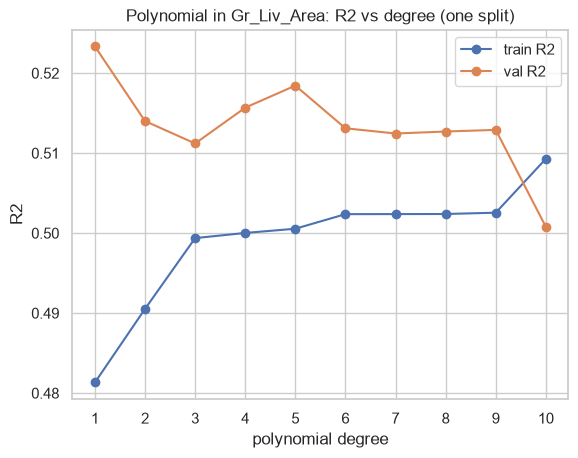

In [27]:
poly_rows = []
for degree in range(1, 11):
    poly = polynomial_model(degree).fit(train[["Gr_Liv_Area"]], y_train)
    poly_rows.append({
        "degree": degree,
        "train_r2": poly.score(train[["Gr_Liv_Area"]], y_train),
        "val_r2": poly.score(val[["Gr_Liv_Area"]], y_val),
    })
poly_table = pd.DataFrame(poly_rows)
print(poly_table)

plt.plot(poly_table["degree"], poly_table["train_r2"], marker="o",
         label="train R2")
plt.plot(poly_table["degree"], poly_table["val_r2"], marker="o",
         label="val R2")
plt.xticks(poly_table["degree"])
plt.xlabel("polynomial degree")
plt.ylabel("R2")
plt.title("Polynomial in Gr_Liv_Area: R2 vs degree (one split)")
plt.legend()
plt.show()

In [28]:
grader.check("q7_1")

q7_1 results: All test cases passed!

### Q7.2 Training and validation curves

Training R² cannot fall as the degree rises. The solver can set every new coefficient to
zero and recover the lower-degree fit.

<div class=prompt>

**Artifact:** `best_degree_single_split`: the degree with the highest validation R² in
`poly_table`.

**Written answer:**
- the degree at which validation R² is highest;
- `val["Gr_Liv_Area"].max()`;
- one sentence, using the curve plot: why a degree-10 fit does not help below that value.
</div>


In [29]:
best_degree_single_split = int(
    poly_table.loc[poly_table["val_r2"].idxmax(), "degree"])
print("best degree on val:", best_degree_single_split)
val_max = val["Gr_Liv_Area"].max()
print("largest Gr_Liv_Area in val:", val_max)
print("largest Gr_Liv_Area in train:", train["Gr_Liv_Area"].max())
n_larger = int((train["Gr_Liv_Area"] > val_max).sum())
print("train houses larger than the largest val house:", n_larger)

best degree on val: 1
largest Gr_Liv_Area in val: 3672
largest Gr_Liv_Area in train: 5095
train houses larger than the largest val house: 4


Validation R² is highest at degree 1 (0.523), and the largest house in val has 3,672 sq ft. Below that size the degree-10 curve mostly follows the straight line; its extra bends go to the four training houses larger than 3,672 sq ft, which no val house resembles, so it adds wiggles without information and even drifts off the line for the few val houses just under that size.

In [30]:
grader.check("q7_2")

q7_2 results: All test cases passed!

## Question 8: Cross-validation

### Q8.1 Cross-validated degree scan

Use **all of `dev`** (2,197 rows) with the fold splitter below. `train` and `val` are not
used here.


In [31]:
# Provided: the fold splitter every cross-validation in Part 3 uses.
kfold = KFold(n_splits=5, shuffle=True, random_state=0)

<div class=prompt>

**Artifact:**
- `cv_table`: one row per degree from 1 to 10 with columns `degree`, `cv_mean` (mean of
  the five fold R² scores from `cross_val_score(model, X, y, cv=kfold, scoring="r2")`)
  and `cv_std` (`scores.std(ddof=1)`);
- `fold_scores`: a dict from degree to the array of its five fold scores; Q8.2 uses it;
- a plot of `cv_mean` against degree with `cv_std` as error bars (`plt.errorbar`). Some
  degrees score far below zero: clip the vertical axis so the degrees near the top stay
  readable, and mark the clipped values.
</div>


   degree   cv_mean     cv_std
0       1  0.486710   0.049416
1       2  0.490987   0.041199
2       3  0.492883   0.049973
3       4  0.490170   0.050788
4       5  0.494325   0.050951
5       6  0.436394   0.131568
6       7 -0.040093   1.123913
7       8 -2.248383   6.031752
8       9 -3.322190   8.409626
9      10 -7.566905  17.853559


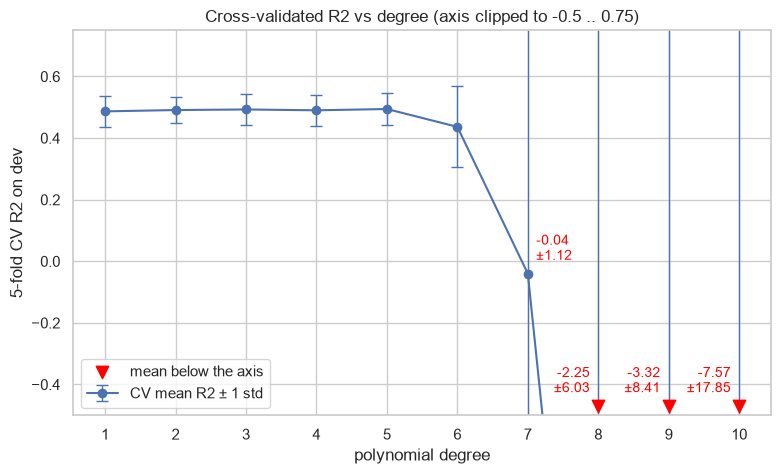

In [32]:
fold_scores = {}
for degree in range(1, 11):
    fold_scores[degree] = cross_val_score(
        polynomial_model(degree), dev[["Gr_Liv_Area"]],
        dev["Sale_Price"], cv=kfold, scoring="r2")
cv_table = pd.DataFrame({
    "degree": list(fold_scores),
    "cv_mean": [scores.mean() for scores in fold_scores.values()],
    "cv_std": [scores.std(ddof=1) for scores in fold_scores.values()],
})
print(cv_table)

y_bottom, y_top = -0.5, 0.75
plt.figure(figsize=(9, 5))
plt.errorbar(cv_table["degree"], cv_table["cv_mean"],
             yerr=cv_table["cv_std"], marker="o", capsize=4,
             elinewidth=1, label="CV mean R2 ± 1 std")
# What the clipped axis hides: a red triangle where the mean is below
# the axis, and the mean ± std written out for every degree whose
# error bar runs past either limit.
below = cv_table[cv_table["cv_mean"] < y_bottom]
plt.scatter(below["degree"], [y_bottom + 0.03] * len(below),
            marker="v", s=80, color="red", zorder=3,
            label="mean below the axis")
bar_low = cv_table["cv_mean"] - cv_table["cv_std"]
bar_high = cv_table["cv_mean"] + cv_table["cv_std"]
cut = cv_table[(bar_low < y_bottom) | (bar_high > y_top)]
for _, row in cut.iterrows():
    on_axis = row["cv_mean"] >= y_bottom
    plt.annotate(f"{row['cv_mean']:.2f}\n±{row['cv_std']:.2f}",
                 (row["degree"], max(row["cv_mean"], y_bottom + 0.03)),
                 textcoords="offset points",
                 xytext=(6, 10) if on_axis else (-6, 10),
                 ha="left" if on_axis else "right",
                 color="red", fontsize=10)
plt.ylim(y_bottom, y_top)
plt.xticks(cv_table["degree"])
plt.xlabel("polynomial degree")
plt.ylabel("5-fold CV R2 on dev")
plt.title(f"Cross-validated R2 vs degree "
          f"(axis clipped to {y_bottom} .. {y_top})")
plt.legend(loc="lower left")
plt.show()

In [33]:
grader.check("q8_1")

q8_1 results: All test cases passed!

### Q8.2 Choose the degree

To see one fold's rows: `for fold, (fit_idx, val_idx) in enumerate(kfold.split(dev))`
yields each fold's row positions, and `dev.iloc[val_idx]` is that fold's validation rows.

<div class=prompt>

**Artifact:** `cv_degree`: the degree you would choose from `cv_table`. One rule: take the
highest mean, subtract one standard error (`cv_std / sqrt(5)`), and choose the smallest
degree whose mean clears that line. Say which rule you used.

**Written answer:**
- the degree chosen by the single split (Q7.2), by the highest CV mean, and by your rule;
- for degree 7, the fold with the lowest score, and the largest `Gr_Liv_Area` among its
  validation rows;
- one sentence: what the fold-to-fold variation shows that the mean does not.
</div>


In [34]:
# Rule: one standard error. Take the highest mean, subtract
# cv_std / sqrt(5) of that degree, and choose the smallest degree
# whose mean clears the line.
best_row = cv_table.loc[cv_table["cv_mean"].idxmax()]
line = best_row["cv_mean"] - best_row["cv_std"] / np.sqrt(5)
clears = cv_table["cv_mean"] >= line
cv_degree = int(cv_table.loc[clears, "degree"].min())
print("single split (Q7.2):", best_degree_single_split)
print("highest CV mean:", int(best_row["degree"]),
      f"({best_row['cv_mean']:.4f})")
print(f"one-SE line: {line:.4f} -> chosen degree:", cv_degree)

print("degree 7 fold scores:", fold_scores[7].round(3))
worst_fold = int(np.argmin(fold_scores[7]))
fit_idx, val_idx = list(kfold.split(dev))[worst_fold]
fold_fit, fold_val = dev.iloc[fit_idx], dev.iloc[val_idx]
print(f"worst fold: {worst_fold} (counting from 0), "
      f"R2 {fold_scores[7][worst_fold]:.3f}")
print("largest Gr_Liv_Area in its validation rows:",
      fold_val["Gr_Liv_Area"].max())
print("largest Gr_Liv_Area in its fitting rows:",
      fold_fit["Gr_Liv_Area"].max())

# What the degree-7 fit of that fold does to its largest held-out
# house, and the fold's score with that one house left out.
deg7 = polynomial_model(7).fit(fold_fit[["Gr_Liv_Area"]],
                               fold_fit["Sale_Price"])
fold_pred = pd.Series(deg7.predict(fold_val[["Gr_Liv_Area"]]),
                      index=fold_val.index)
largest = fold_val["Gr_Liv_Area"].idxmax()
print(f"that house: predicted ${fold_pred[largest]:,.0f}, "
      f"sold for ${fold_val.loc[largest, 'Sale_Price']:,}")
others = fold_val.index != largest
r2_others = r2_score(fold_val.loc[others, "Sale_Price"],
                     fold_pred[others])
print(f"R2 of the fold without that house: {r2_others:.3f}")

single split (Q7.2): 1
highest CV mean: 5 (0.4943)
one-SE line: 0.4715 -> chosen degree: 1
degree 7 fold scores: [ 0.327  0.468  0.478  0.571 -2.045]


worst fold: 4 (counting from 0), R2 -2.045
largest Gr_Liv_Area in its validation rows: 5095
largest Gr_Liv_Area in its fitting rows: 4676
that house: predicted $-2,421,824, sold for $183,850
R2 of the fold without that house: 0.513


The single split (Q7.2) picks degree 1, the highest CV mean is at degree 5 (0.494), and my rule, the one-standard-error rule, picks degree 1: one standard error below the best mean is 0.4715, and degree 1 already clears it with 0.487. For degree 7 the worst fold is fold 4 (counting from 0, R² -2.05), and the largest house among its validation rows has 5,095 sq ft, more than any house that fold was fitted on (4,676 at most). The fold-to-fold variation shows what the mean of -0.04 hides: degree 7 scores 0.33 to 0.57 on four folds and collapses on the one where it must extrapolate to a single oversized house (it predicts about -2.4 million dollars for a house that sold for 183,850; without that house the fold scores 0.51).

In [35]:
grader.check("q8_2")

q8_2 results: All test cases passed!

## Question 9: The final pipeline

Q4, Q5 and Q6 each tested one addition on its own. This question puts the numeric
columns, `Neighborhood`, `Overall_Qual` and `Central_Air` into one pipeline and
cross-validates it. Every step that learns from the data, scaling and encoding included,
must be fitted inside the cross-validation loop on that fold's training rows. A
`Pipeline` does that. `pd.get_dummies` outside a pipeline cannot.

The provided cell below shows scikit-learn's two preprocessing steps on a small example.
It also shows the object that applies each step to its own columns.

- `OneHotEncoder(handle_unknown="ignore", drop="first")` is `pd.get_dummies(...,
  drop_first=True)` as a fitted step; `handle_unknown="ignore"` encodes a level that was
  absent when fitting as all zeros.
- `StandardScaler()` standardises each numeric column.
- `ColumnTransformer([...])` applies a different step to each list of columns and joins
  the results.


In [36]:
# Provided: the three pieces on a small example: two numeric columns and one categorical.
example_numeric = ["Gr_Liv_Area", "Year_Built"]
example_categorical = ["Central_Air"]

example_prep = ColumnTransformer([
    ("num", StandardScaler(), example_numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), example_categorical),
])
example_pipeline = Pipeline([
    ("prep", example_prep),
    ("reg", LinearRegression()),
])

# Fitting the pipeline fits the scaler, the encoder AND the regression on the same rows.
example_pipeline.fit(train[example_numeric + example_categorical], train["Sale_Price"])

print("columns the regression receives:", list(example_pipeline["prep"].get_feature_names_out()))
print("coefficients:", example_pipeline["reg"].coef_.round(0))
print(f"validation R2: {example_pipeline.score(val[example_numeric + example_categorical], val['Sale_Price']):.3f}")

# The same object can be handed to cross_val_score: every fold refits all three steps on
# its own training rows. When a fold's held-out rows contain a level the training rows did
# not (Landmark), the encoder reports it once and encodes the row as all zeros.
example_cv = cross_val_score(example_pipeline, dev[example_numeric + example_categorical], dev["Sale_Price"],
                             cv=kfold, scoring="r2")
print("5-fold CV R2:", example_cv.round(3), "-> mean", example_cv.mean().round(3))

columns the regression receives: ['num__Gr_Liv_Area', 'num__Year_Built', 'cat__Central_Air_Y']
coefficients: [47653. 32473. 12281.]
validation R2: 0.694
5-fold CV R2: [0.608 0.648 0.681 0.703 0.646] -> mean 0.657


<div class=prompt>

**Artifact:**
- `final_pipeline`: a `Pipeline` whose first step is a `ColumnTransformer` applying
  `StandardScaler()` to `NUMERIC_COLS` and
  `OneHotEncoder(handle_unknown="ignore", drop="first")` to
  `["Central_Air", "Neighborhood", "Overall_Qual"]`, and whose last step is
  `LinearRegression()`. Build it exactly as specified: one-hot for `Overall_Qual`, even if
  you preferred the ordinal encoding in Q6;
- `final_cv_scores`: the five fold R² scores from `cross_val_score(final_pipeline, ...)`
  on `dev` with `kfold`. Print their mean and standard deviation.

**Written answer:**
- what `handle_unknown="ignore"` gives a held-out row whose neighbourhood was absent from
  the fold's training rows;
- which of Q5's, Q6's and this question's scores you would report, named.
</div>


In [37]:
FINAL_CATEGORICAL = ["Central_Air", "Neighborhood", "Overall_Qual"]
FINAL_COLS = NUMERIC_COLS + FINAL_CATEGORICAL
final_prep = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"),
     FINAL_CATEGORICAL),
])
final_pipeline = Pipeline([
    ("prep", final_prep),
    ("reg", LinearRegression()),
])

# One fold's held-out rows contain neighbourhoods its fitting rows
# lack. The encoder says so in a warning; catch it and print the
# message.
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    final_cv_scores = cross_val_score(
        final_pipeline, dev[FINAL_COLS], dev["Sale_Price"],
        cv=kfold, scoring="r2")
for warning in caught:
    print("encoder warning:", warning.message)
print("fold R2:", final_cv_scores.round(4))
print(f"mean {final_cv_scores.mean():.4f}, "
      f"std {final_cv_scores.std(ddof=1):.4f}")
print(f"for comparison: Q5 val R2 {nbhd_val_r2:.4f}, "
      f"Q6 one-hot val R2 {qual_onehot_val_r2:.4f}")

encoder warning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
fold R2: [0.8206 0.8986 0.8896 0.8716 0.8095]
mean 0.8580, std 0.0406
for comparison: Q5 val R2 0.8190, Q6 one-hot val R2 0.8489


A held-out house from a neighbourhood the fold never saw gets 0 in every Neighborhood column, so it is priced like a house in the baseline neighbourhood (Bloomington_Heights), with its other columns used as usual. I would report Q9's 5-fold CV R² of 0.858 (std 0.041). It scores the model we actually keep, it averages five held-out folds where Q5 (0.819) and Q6 (0.849) each rest on one train/val split, and it refits the scaler and the encoder inside each fold.

In [38]:
grader.check("q9")

q9 results: All test cases passed!

## AC209A: Bias and variance

*Required for AC209A students; CS1090A students skip this question.*

Q8.2 traced the collapse of the high-degree polynomial to one house the model was not
fitted near. This question measures the mechanism. The prediction error at a house has two
parts. **Bias** is how far the average prediction, over many fits on different training
samples, sits from the truth. **Variance** is how much the prediction moves from one fit
to the next. The bootstrap estimates both without new data. Refit on many resamples of the training
rows, drawn with replacement, and look at the predictions each validation house receives.

<div class=prompt>

**Artifact:**
- from `dev_df` (all 81 columns), rank the numeric columns by the absolute value of
  their correlation with `Sale_Price`; print the ranking. Use `Gr_Liv_Area`,
  `Total_Bsmt_SF`, `Garage_Cars`, `Year_Built` as predictors: the top of that ranking
  after removing `Garage_Area` and `First_Flr_SF`, each a near-copy of a column already
  in the list;
- for each degree from 1 to 6, fit `polynomial_model(degree)` on 100 bootstrap resamples
  of `train` (drawn with replacement) and predict `Sale_Price` for `val` each time.
  From the 100 × 550 predictions compute, averaged over validation houses: **bias²**, the
  squared difference between the mean prediction and the actual price; **variance**, the
  variance of the 100 predictions; **total** mean squared error averaged over the fits.
  Report them in `bv_table` with columns `degree`, `bias2`, `variance`, `total_mse`, and
  plot all three against degree on a log vertical axis. Fix a random seed and keep the
  cell under two minutes;
- in a comment, why the bias² you computed also contains the irreducible noise in prices,
  and why that does not affect the comparison across degrees.

**Written answer:**
- the degree with the smallest total;
- which component, bias² or variance, explains the Q8.2 collapse;
- whether bias² falls while variance rises across the degrees: yes, partly, or no.
</div>


Gr_Liv_Area           0.701
Total_Bsmt_SF         0.651
Garage_Cars           0.647
Garage_Area           0.644
First_Flr_SF          0.630
Year_Built            0.550
Year_Remod_Add        0.534
Full_Bath             0.533
TotRms_AbvGrd         0.488
Mas_Vnr_Area          0.479
Fireplaces            0.470
Wood_Deck_SF          0.324
Open_Porch_SF         0.314
Latitude              0.289
Half_Bath             0.283
Bsmt_Full_Bath        0.280
Lot_Area              0.264
Second_Flr_SF         0.252
Longitude             0.248
Lot_Frontage          0.202
Bsmt_Unf_SF           0.195
BsmtFin_SF_1          0.144
Enclosed_Porch        0.135
Bedroom_AbvGr         0.132
Kitchen_AbvGr         0.119
Screen_Porch          0.106
Pool_Area             0.084
Bsmt_Half_Bath        0.045
Low_Qual_Fin_SF       0.038
BsmtFin_SF_2          0.031
Mo_Sold               0.030
Three_season_porch    0.026
Misc_Val              0.023
Year_Sold             0.009


bootstrap took 3.4 s
   degree         bias2      variance     total_mse
0       1  1.370217e+09  2.062163e+07  1.390839e+09
1       2  1.271662e+09  7.689603e+07  1.348558e+09
2       3  1.209756e+09  1.651767e+08  1.374933e+09
3       4  1.108317e+09  8.061642e+08  1.914481e+09
4       5  4.153901e+09  1.150025e+10  1.565415e+10
5       6  1.155139e+10  5.384288e+10  6.539428e+10


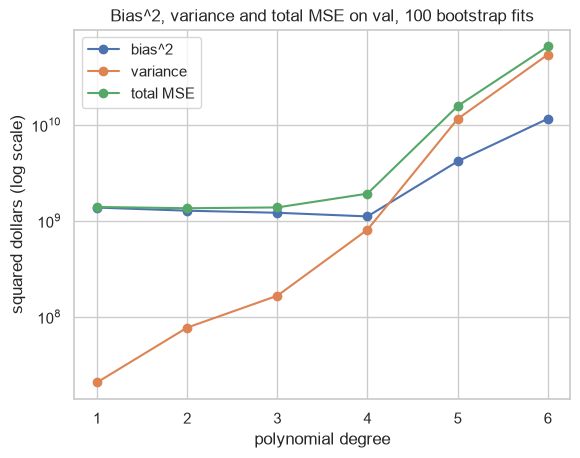

degree with the smallest total: 2
the 3 most variable val houses carry 75% of the degree-6 variance and 84% of its bias2


In [39]:
# Rank the numeric columns of the full file (dev rows only) by
# |correlation| with Sale_Price.
dev_numeric = dev_df.select_dtypes("number")
corr_rank = (dev_numeric.drop(columns="Sale_Price")
             .corrwith(dev_numeric["Sale_Price"])
             .abs().sort_values(ascending=False))
print(corr_rank.round(3).to_string())

BV_PREDICTORS = ["Gr_Liv_Area", "Total_Bsmt_SF", "Garage_Cars",
                 "Year_Built"]
N_BOOT = 100
rng = np.random.default_rng(109)
# The same 100 resamples of train (rows drawn with replacement) are
# used for every degree, so the degrees are compared on identical
# samples.
boot_rows = rng.integers(0, len(train), size=(N_BOOT, len(train)))
y_val_arr = y_val.to_numpy()

# bias2 here is (mean prediction - actual price)^2. An actual price is
# the expected price of such a house plus noise that these four
# columns cannot explain. Averaged over the val houses, bias2 as
# computed is therefore the true bias^2 plus the variance of that
# noise. The noise belongs to the houses, not to the model: on average
# it adds the same amount at every degree, so it does not change which
# degree is better.
bv_rows = []
bv_start = time.time()
for degree in range(1, 7):
    preds = np.empty((N_BOOT, len(val)))
    for b in range(N_BOOT):
        boot = train.iloc[boot_rows[b]]
        boot_model = polynomial_model(degree).fit(boot[BV_PREDICTORS],
                                                  boot["Sale_Price"])
        preds[b] = boot_model.predict(val[BV_PREDICTORS])
    bv_rows.append({
        "degree": degree,
        "bias2": ((preds.mean(axis=0) - y_val_arr) ** 2).mean(),
        "variance": preds.var(axis=0).mean(),
        "total_mse": ((preds - y_val_arr) ** 2).mean(),
    })
bv_table = pd.DataFrame(bv_rows)
print(f"bootstrap took {time.time() - bv_start:.1f} s")
print(bv_table)

for col, label in [("bias2", "bias^2"), ("variance", "variance"),
                   ("total_mse", "total MSE")]:
    plt.plot(bv_table["degree"], bv_table[col], marker="o", label=label)
plt.yscale("log")
plt.xlabel("polynomial degree")
plt.ylabel("squared dollars (log scale)")
plt.title("Bias^2, variance and total MSE on val, 100 bootstrap fits")
plt.legend()
plt.show()
best_bv_degree = int(bv_table.loc[bv_table["total_mse"].idxmin(),
                                  "degree"])
print("degree with the smallest total:", best_bv_degree)

# preds now holds the degree-6 predictions: how much of the error sits
# in a few val houses?
house_var = preds.var(axis=0)
house_bias2 = (preds.mean(axis=0) - y_val_arr) ** 2
top3 = np.argsort(house_var)[-3:]
var_share = house_var[top3].sum() / house_var.sum()
bias2_share = house_bias2[top3].sum() / house_bias2.sum()
print(f"the 3 most variable val houses carry {var_share:.0%} of the "
      f"degree-6 variance and {bias2_share:.0%} of its bias2")

Total MSE is smallest at degree 2. Variance explains the Q8.2 collapse: it grows at every degree, from about 2.1e7 at degree 1 to 5.4e10 at degree 6, and overtakes bias² at degree 5, so a high-degree fit swings with whichever houses land in its sample, as degree 7 did in Q8.2 over one 5,095 sq ft house. Partly: bias² falls from degree 1 to 4 while variance rises, but it climbs again at degrees 5 and 6, because a few unusual val houses get predictions so extreme that even the average of 100 fits is far off (the 3 most variable houses carry 75% of the degree-6 variance and 84% of its bias²).

## Wrap-up

### Test set score

No model has been fitted on the 733 houses in `test`, and nothing has been scored on them.
Fit `final_pipeline` on all of `dev` and score it on `test`, **once**. If the number
disappoints, do not try another model. That would turn `test` into a validation set.

<div class=prompt>

**Artifact:**
- `test_r2`: R² of `final_pipeline`, fitted on `dev`, on `test`;
- `test_rmse`: root-mean-squared error of the same predictions, in dollars. Compute it as
  `np.sqrt(mean_squared_error(actual, predicted))`.

**Written answer** (required):
- one sentence answering the opening question with `test_r2` and `test_rmse`;
- one reason the test score is optimistic about the next house listed in Ames, from how
  the test rows were drawn;
- one reason it is pessimistic, from how many rows the final model was fitted on.
</div>

<div class="alert alert-info" style="color: #4a4a4a; background-color: #fbe8ff; border-color: #eed4db; border-width: 1px; border-radius: 3px; padding: 10px;">

* (Optional) Which aspect of the assignment did you find most challenging?

* How many hours did you spend on this assignment? Store an int or float in
  `hours_spent_on_hw` (if you worked in a group, report the average per person).

</div>

In [40]:
final_pipeline.fit(dev[FINAL_COLS], dev["Sale_Price"])
test_pred = final_pipeline.predict(test[FINAL_COLS])
test_r2 = r2_score(test["Sale_Price"], test_pred)
test_rmse = np.sqrt(mean_squared_error(test["Sale_Price"], test_pred))
print(f"test R2: {test_r2:.4f}")
print(f"test RMSE: ${test_rmse:,.0f}")
# Same predictions, no refit: the size of the middle miss, to read
# next to the RMSE.
test_median_miss = np.median(np.abs(test["Sale_Price"] - test_pred))
print(f"median absolute error: ${test_median_miss:,.0f}")

test R2: 0.8168
test RMSE: $35,146
median absolute error: $12,742


On 733 houses it never saw, the final model explains about 82% of the variation in sale price (test R² 0.817) with an RMSE of 35,146 dollars, so its estimate is a fair first guess for an ordinary house, where half the predictions miss by less than 12,742 dollars, but deserves little trust for an unusual one, whose large misses drive the RMSE. Optimistic: the test houses are a random quarter of the same 2006 to 2010 sales, so they share the training years and market, while the next house listed will sell later, in a market the data never saw. Pessimistic: the scored model was fitted on only the 2,197 dev houses; the one we would actually use would be refitted on all 2,930, and more data usually gives a slightly better fit.

In [41]:
hours_spent_on_hw = 8

In [42]:
grader.check("wrapup")

wrapup results: All test cases passed!

In [43]:
notebook_end = time.time()
print(f"It took {(notebook_end - notebook_start)/60:.2f} minutes for this notebook to run")

It took 0.08 minutes for this notebook to run
